# Modern ML Baselines: Prophet and XGBoost

**Outline**
1. Load data
2. Prophet — multiplicative seasonality, US holidays, cross-validation, component plots
3. XGBoost — lag/calendar feature engineering, early stopping, SHAP importances
4. Metrics: RMSE, MAE, MAPE
5. Side-by-side forecast plot and export

---

## Step 0: Imports

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import logging
import warnings
warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)  # suppress per-fold Stan logs

from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

import xgboost as xgb
import shap

from sklearn.metrics import mean_absolute_error

os.makedirs('../outputs/figures', exist_ok=True)

## Step 1: Load Data

In [34]:
train = pd.read_csv('../data/daily_train.csv', index_col='datetime', parse_dates=True)
test  = pd.read_csv('../data/daily_test.csv',  index_col='datetime', parse_dates=True)

train_series = train['power']
test_series  = test['power']

print(f"Train: {train_series.index.min().date()} → {train_series.index.max().date()} ({len(train_series)} obs)")
print(f"Test:  {test_series.index.min().date()}  → {test_series.index.max().date()} ({len(test_series)} obs)")

Train: 2006-12-16 → 2009-11-30 (1081 obs)
Test:  2009-12-01  → 2010-11-26 (361 obs)


## Step 2: Prophet

### 2.1 Fit

Multiplicative seasonality is appropriate for the same reason as ETS — winter variance scales with the series level rather than being a fixed additive offset. US holidays are added as a regressor; the dataset covers a French household, but the holiday calendar is a useful structural prior and can be swapped if a French calendar is available.

In [35]:
# Prophet requires columns named ds (date) and y (target)
prophet_train = train_series.reset_index().rename(columns={'datetime': 'ds', 'power': 'y'})

model_prophet = Prophet(
    seasonality_mode='multiplicative',
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    uncertainty_samples=500,
    interval_width=0.95
)
model_prophet.add_country_holidays(country_name='US')
model_prophet.fit(prophet_train)

### 2.2 Cross-Validation

Prophet's built-in cross-validation is a methodological advantage worth noting: it performs a proper walk-forward evaluation by fitting the model on progressively larger training windows and scoring each horizon independently. This is more informative than a single train/test split because it shows how error accumulates as the forecast horizon extends.

In [36]:
df_cv = cross_validation(
    model_prophet,
    initial='366 days',   # minimum training window for each fold
    period='30 days',     # how often to advance the cutoff
    horizon='30 days',   # forecast window evaluated per fold — capped by training length
    parallel='threads',
)

df_perf = performance_metrics(df_cv)
print(df_perf[['horizon', 'rmse', 'mae', 'mape']].to_string(index=False))

horizon     rmse      mae     mape
 3 days 0.263028 0.186854 0.249522
 4 days 0.279039 0.194136 0.233990
 5 days 0.296858 0.212949 0.248036
 6 days 0.278469 0.211287 0.255194
 7 days 0.273571 0.210557 0.272186
 8 days 0.272410 0.213440 0.281118
 9 days 0.292200 0.226042 0.324624
10 days 0.322384 0.248269 0.379574
11 days 0.315791 0.239522 0.365076
12 days 0.310929 0.243134 0.346113
13 days 0.312620 0.249463 0.332442
14 days 0.319150 0.254382 0.356963
15 days 0.303008 0.238260 0.355126
16 days 0.297986 0.231585 0.391499
17 days 0.310691 0.244351 0.442203
18 days 0.340133 0.277383 0.481514
19 days 0.357120 0.293394 0.478212
20 days 0.391035 0.306027 0.471886
21 days 0.387519 0.290122 0.464527
22 days 0.355607 0.259497 0.443824
23 days 0.331220 0.251624 0.440649
24 days 0.335319 0.244313 0.393800
25 days 0.336638 0.238782 0.342866
26 days 0.334515 0.236349 0.284639
27 days 0.325163 0.235839 0.261071
28 days 0.318196 0.241218 0.245356
29 days 0.322242 0.246974 0.260702
30 days 0.321755 0.2

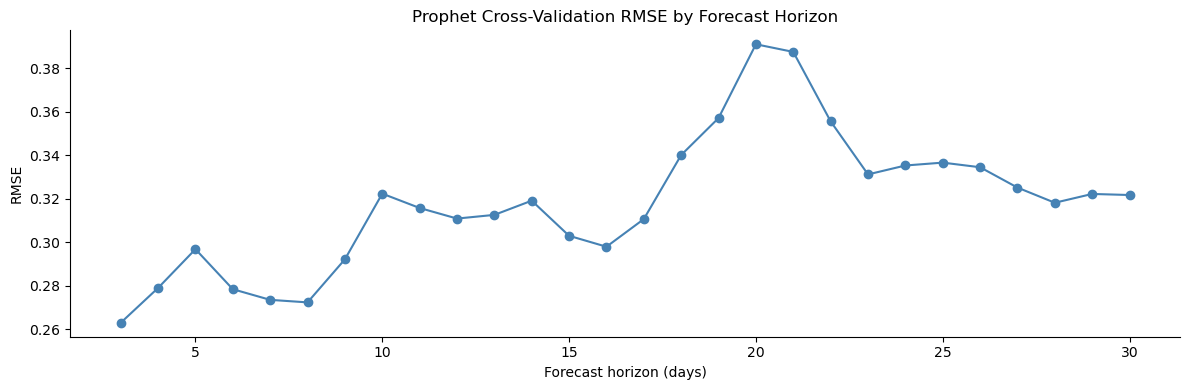

Saved → ../outputs/figures/prophet_cv_rmse.png


In [37]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_perf['horizon'].dt.days, df_perf['rmse'], marker='o', linewidth=1.5, color='steelblue')
ax.set_xlabel('Forecast horizon (days)')
ax.set_ylabel('RMSE')
ax.set_title('Prophet Cross-Validation RMSE by Forecast Horizon')
sns.despine()
plt.tight_layout()
plt.savefig('../outputs/figures/prophet_cv_rmse.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../outputs/figures/prophet_cv_rmse.png")

### 2.3 Walk-Forward Forecast

`forecast_prophet` (the single-fit prediction over the full future) is retained for the component decomposition plot below. The walk-forward loop then refits Prophet at each fold on the expanding context so the evaluation uses the same strategy as every other model in the project.

In [38]:
# Single-fit forecast — used only for the component decomposition plot in the next cell
h = len(test_series)
future = model_prophet.make_future_dataframe(periods=h)
forecast_prophet = model_prophet.predict(future)

# Walk-forward evaluation — refit Prophet at each fold with expanding context
FOLD_SIZE   = 30
fold_starts = list(range(0, len(test_series), FOLD_SIZE))

prophet_preds_list = []
prophet_context    = train_series.copy()

for i, start in enumerate(fold_starts):
    end      = min(start + FOLD_SIZE, len(test_series))
    fold_len = end - start

    df_fold = prophet_context.reset_index().rename(columns={'datetime': 'ds', 'power': 'y'})
    m = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        uncertainty_samples=0,  # skip uncertainty to speed up each refit
    )
    m.add_country_holidays(country_name='US')
    m.fit(df_fold)

    future_fold = m.make_future_dataframe(periods=fold_len)
    fc          = m.predict(future_fold)
    preds       = fc.set_index('ds')['yhat'].tail(fold_len)
    preds.index = test_series.index[start:end]
    prophet_preds_list.append(preds)

    prophet_context = pd.concat([prophet_context, test_series.iloc[start:end]])
    print(f"  Prophet fold {i+1}/{len(fold_starts)}: days {start+1}–{end}")

prophet_forecast = pd.concat(prophet_preds_list)
print(f"\nCompleted {len(fold_starts)} folds covering {len(prophet_forecast)} test days")

  Prophet fold 1/13: days 1–30
  Prophet fold 2/13: days 31–60
  Prophet fold 3/13: days 61–90
  Prophet fold 4/13: days 91–120
  Prophet fold 5/13: days 121–150
  Prophet fold 6/13: days 151–180
  Prophet fold 7/13: days 181–210
  Prophet fold 8/13: days 211–240
  Prophet fold 9/13: days 241–270
  Prophet fold 10/13: days 271–300
  Prophet fold 11/13: days 301–330
  Prophet fold 12/13: days 331–360
  Prophet fold 13/13: days 361–361

Completed 13 folds covering 361 test days


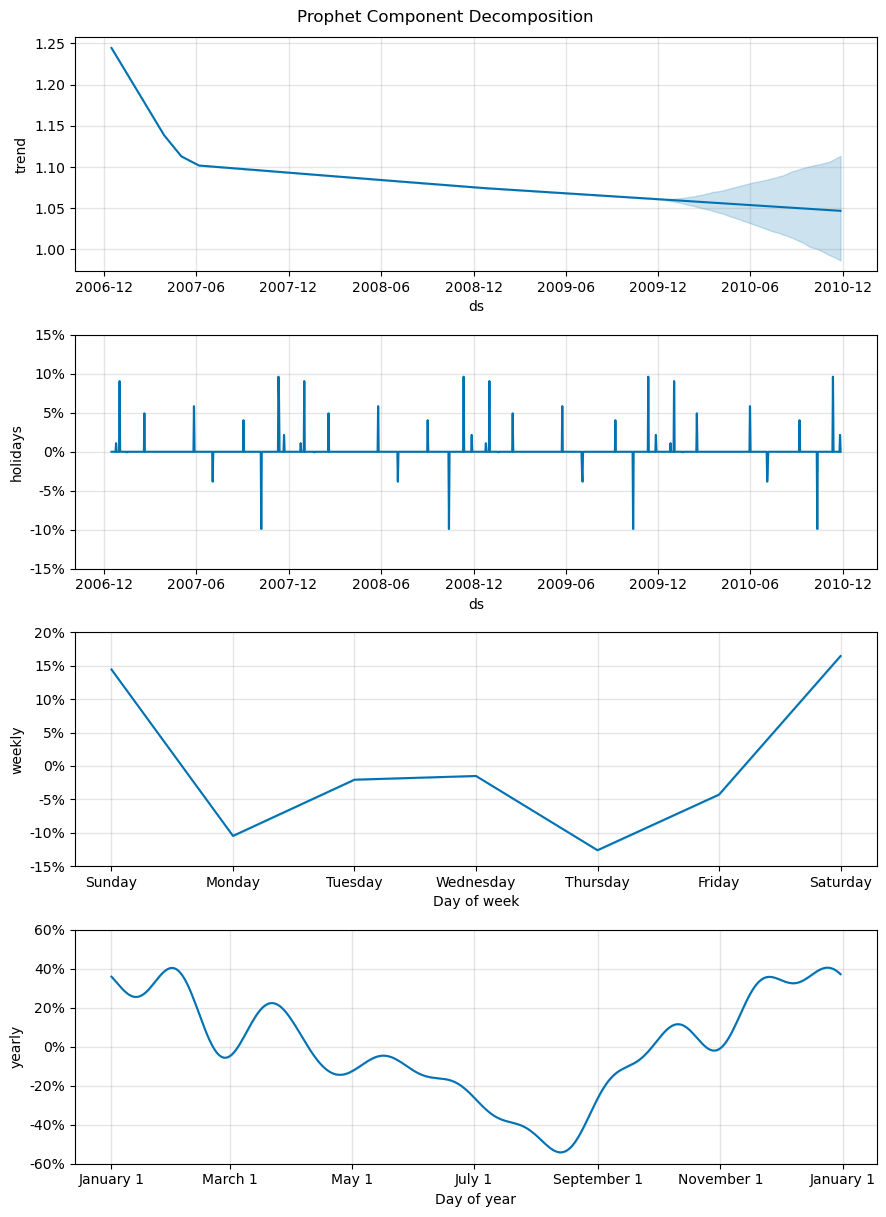

Saved → ../outputs/figures/prophet_components.png


In [39]:
fig_comp = model_prophet.plot_components(forecast_prophet)
fig_comp.suptitle('Prophet Component Decomposition', y=1.01)
fig_comp.savefig('../outputs/figures/prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../outputs/figures/prophet_components.png")

## Step 3: XGBoost

### 3.1 Feature Engineering

Tree models have no native concept of temporal order — XGBoost cannot learn that yesterday's power consumption predicts today's the way an ARIMA term does. The feature matrix below reconstructs that temporal structure explicitly.

**Data leakage guard:** Every rolling statistic uses `.shift(1)` before the window calculation. Without the shift, the rolling mean at time *t* would include the value at time *t* itself, meaning the model would see the target it is trying to predict as part of its own features. The shift ensures each feature uses only information available *before* the current observation.

**Sub-metering lags** give XGBoost a multivariate signal: yesterday's and last-week's kitchen, laundry, and heating consumption are informative predictors of total power that the univariate lag features alone cannot capture.

In [40]:
def make_features(df):
    # retain only the columns used for feature engineering — prevents contemporaneous
    # measurements (voltage, current, reactive_power) from leaking into the feature matrix
    df = df[['power', 'sub_meter_kitchen', 'sub_meter_laundry', 'sub_meter_heating']].copy()
    # lag features
    for lag in [1, 7, 14, 30]:
        df[f'lag_{lag}'] = df['power'].shift(lag)
    # rolling statistics — .shift(1) prevents the current day's value from leaking into its own features
    df['rolling_mean_7']  = df['power'].shift(1).rolling(7).mean()
    df['rolling_mean_30'] = df['power'].shift(1).rolling(30).mean()
    df['rolling_std_7']   = df['power'].shift(1).rolling(7).std()
    # calendar features
    df['day_of_week']  = df.index.dayofweek
    df['month']        = df.index.month
    df['day_of_year']  = df.index.dayofyear
    df['is_weekend']   = (df.index.dayofweek >= 5).astype(int)
    # sub-metering lag features
    for col in ['sub_meter_kitchen', 'sub_meter_laundry', 'sub_meter_heating']:
        df[f'{col}_lag_1'] = df[col].shift(1)
        df[f'{col}_lag_7'] = df[col].shift(7)
        df.drop(columns=col, inplace=True)  # drop the unshifted column — it's contemporaneous
    return df.dropna()

In [41]:
# Build features on the full series so test-set lags can reach back into training history.
# Note: lag features for test days use actual observed values, not predictions — appropriate
# for batch evaluation but not real-time deployment (which would require recursive forecasting).
full = pd.concat([train, test])
full_featured = make_features(full)

feature_cols = [c for c in full_featured.columns if c != 'power']

featured_train = full_featured.loc[train.index.intersection(full_featured.index)]
featured_test  = full_featured.loc[test.index.intersection(full_featured.index)]

print(f"Feature matrix: {len(feature_cols)} features")
print(f"Train rows: {len(featured_train)}  |  Test rows: {len(featured_test)}")
featured_train[feature_cols].head(3)

Feature matrix: 17 features
Train rows: 1051  |  Test rows: 361


,lag_1,lag_7,lag_14,lag_30,rolling_mean_7,rolling_mean_30,rolling_std_7,day_of_week,month,day_of_year,is_weekend,sub_meter_kitchen_lag_1,sub_meter_kitchen_lag_7,sub_meter_laundry_lag_1,sub_meter_laundry_lag_7,sub_meter_heating_lag_1,sub_meter_heating_lag_7
datetime,,,,,,,,,,,,,,,,,
2007-01-15,2.090992,1.556500,1.909031,3.053475,1.605114,1.762853,0.421153,0,1,15,0,1777.0,0.0,4215.0,467.0,12991.5,17547.0
2007-01-16,1.492137,1.297954,0.881414,2.354486,1.595919,1.710808,0.423089,1,1,16,0,1099.0,1688.0,2239.0,4267.0,15163.0,9790.0
2007-01-17,1.171114,1.496389,0.704204,1.530435,1.577799,1.671363,0.440342,2,1,17,0,2063.0,771.0,644.0,4456.0,6583.0,11012.0


### 3.2 Train / Validation Split

The validation set is the last 180 days of the training window — half a year provides a seasonally representative signal for early stopping without meaningfully starving the fit.

In [42]:
val_cutoff = featured_train.index.max() - pd.Timedelta(days=180)

fit_df  = featured_train[featured_train.index <= val_cutoff]
val_df  = featured_train[featured_train.index >  val_cutoff]

X_fit,  y_fit  = fit_df[feature_cols],  fit_df['power']
X_val,  y_val  = val_df[feature_cols],  val_df['power']
X_test, y_test = featured_test[feature_cols], featured_test['power']

print(f"Fit window:  {fit_df.index.min().date()} → {fit_df.index.max().date()} ({len(fit_df)} obs)")
print(f"Val window:  {val_df.index.min().date()} → {val_df.index.max().date()} ({len(val_df)} obs)")
print(f"Test window: {featured_test.index.min().date()} → {featured_test.index.max().date()} ({len(featured_test)} obs)")

Fit window:  2007-01-15 → 2009-06-03 (871 obs)
Val window:  2009-06-04 → 2009-11-30 (180 obs)
Test window: 2009-12-01 → 2010-11-26 (361 obs)


### 3.3 Fit with Early Stopping

In [43]:
model_xgb = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    early_stopping_rounds=50,
    eval_metric='rmse',
    random_state=42,
    verbosity=0,
)

model_xgb.fit(
    X_fit, y_fit,
    eval_set=[(X_val, y_val)],
    verbose=100,
)

print(f"\nBest iteration: {model_xgb.best_iteration}")
print(f"Best val RMSE:  {model_xgb.best_score:.4f}")

[0]	validation_0-rmse:0.36922
[100]	validation_0-rmse:0.21314
[138]	validation_0-rmse:0.21306

Best iteration: 88
Best val RMSE:  0.2124


### 3.4 SHAP Feature Importances

SHAP (SHapley Additive exPlanations) values measure each feature's contribution to the model's output across all training observations. Unlike XGBoost's built-in gain metric, SHAP values are directional and additive — the summary plot shows both magnitude (x-axis) and whether high feature values push the prediction up or down (color).

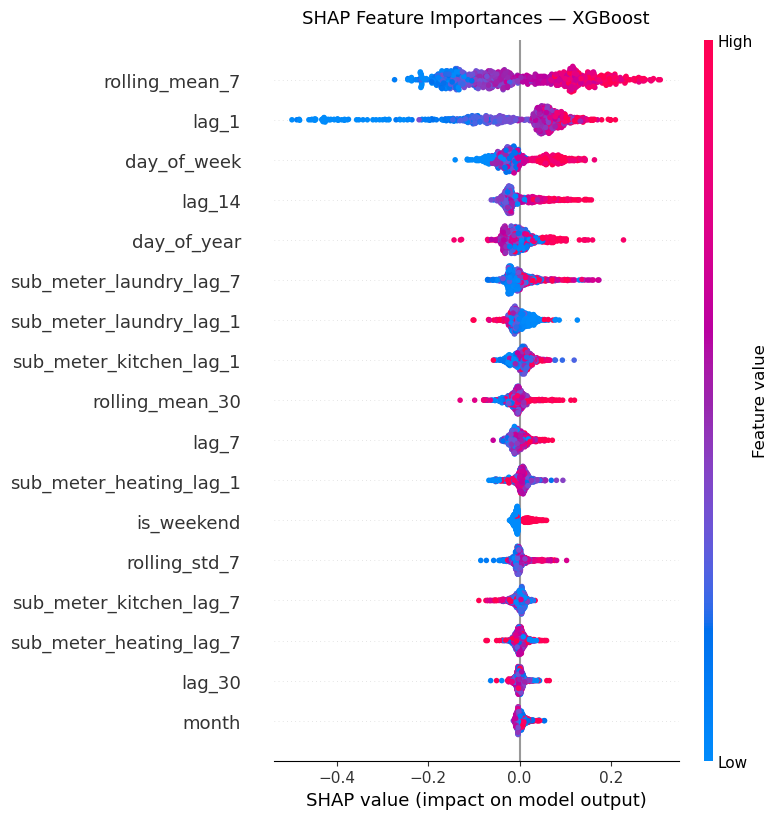

Saved → ../outputs/figures/xgboost_shap_importance.png


In [44]:
explainer   = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_fit)

fig, ax = plt.subplots(figsize=(10, 7))
shap.summary_plot(shap_values, X_fit, plot_type='dot', show=False, max_display=20)
plt.title('SHAP Feature Importances — XGBoost', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('../outputs/figures/xgboost_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../outputs/figures/xgboost_shap_importance.png")

### 3.5 XGBoost Forecast

In [45]:
xgb_preds = model_xgb.predict(X_test)
xgb_forecast = pd.Series(xgb_preds, index=y_test.index)

## Step 4: Metrics

In [46]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

fold_rows = []
for i, start in enumerate(fold_starts):
    end     = min(start + FOLD_SIZE, len(test_series))
    idx     = test_series.index[start:end]
    act     = test_series.loc[idx]
    xgb_idx = idx.intersection(xgb_forecast.index)  # XGBoost may drop early rows due to lag NaNs
    fold_rows.append({
        'Fold':          i + 1,
        'Prophet RMSE':  rmse(act, prophet_forecast.loc[idx]),
        'Prophet MAE':   mean_absolute_error(act, prophet_forecast.loc[idx]),
        'Prophet MAPE':  mape(act, prophet_forecast.loc[idx]),
        'XGBoost RMSE':  rmse(test_series.loc[xgb_idx], xgb_forecast.loc[xgb_idx]),
        'XGBoost MAE':   mean_absolute_error(test_series.loc[xgb_idx], xgb_forecast.loc[xgb_idx]),
        'XGBoost MAPE':  mape(test_series.loc[xgb_idx], xgb_forecast.loc[xgb_idx]),
    })

fold_df = pd.DataFrame(fold_rows).set_index('Fold').round(4)
display(fold_df)

metrics_modern = pd.DataFrame({
    'RMSE': [fold_df['Prophet RMSE'].mean(), fold_df['XGBoost RMSE'].mean()],
    'MAE':  [fold_df['Prophet MAE'].mean(),  fold_df['XGBoost MAE'].mean()],
    'MAPE': [fold_df['Prophet MAPE'].mean(), fold_df['XGBoost MAPE'].mean()],
}, index=['Prophet', 'XGBoost']).round(4)

print(f"\nMean across {len(fold_starts)} folds:")
print(metrics_modern.to_string())
metrics_modern.to_csv('../outputs/modern_ml_metrics.csv')
print("\nSaved → ../outputs/modern_ml_metrics.csv")

,Prophet RMSE,Prophet MAE,Prophet MAPE,XGBoost RMSE,XGBoost MAE,XGBoost MAPE
Fold,,,,,,
1,0.2680,0.1928,16.1274,0.2738,0.1911,14.7867
2,0.2867,0.2173,15.9318,0.2596,0.2185,16.2127
3,0.3337,0.2785,22.0291,0.3327,0.2618,23.2065
4,0.3177,0.2282,27.5903,0.3033,0.2307,25.0494
5,0.1907,0.1437,14.1781,0.1753,0.1325,14.1505
6,0.2003,0.1583,13.4730,0.1853,0.1457,12.8285
7,0.1838,0.1500,15.2082,0.1697,0.1340,15.2325
8,0.1971,0.1533,19.1213,0.1379,0.1079,14.7744
9,0.2539,0.1910,36.0959,0.2147,0.1794,37.6951



Mean across 13 folds:
           RMSE     MAE     MAPE
Prophet  0.2547  0.1965  20.1673
XGBoost  0.2319  0.1815  19.0103

Saved → ../outputs/modern_ml_metrics.csv


In [47]:
classical_path = '../outputs/classical_metrics.csv'

if os.path.exists(classical_path):
    metrics_classical = pd.read_csv(classical_path, index_col=0)
    leaderboard = pd.concat([metrics_classical, metrics_modern]).sort_values('RMSE')
    leaderboard.to_csv('../outputs/leaderboard.csv')
    print("Saved → ../outputs/leaderboard.csv")
else:
    leaderboard = metrics_modern.sort_values('RMSE')
    print("classical_metrics.csv not found — showing modern models only.")

display(
    leaderboard.style
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'MAPE': '{:.2f}%'})
    .background_gradient(cmap='RdYlGn_r', subset=['RMSE', 'MAE', 'MAPE'])
    .set_caption('Model Leaderboard — sorted by RMSE (lower is better)')
)

Saved → ../outputs/leaderboard.csv


,RMSE,MAE,MAPE
XGBoost,0.2319,0.1815,19.01%
SARIMA,0.2381,0.1810,19.69%
Prophet,0.2547,0.1965,20.17%
ETS,0.2841,0.2317,23.99%


## Step 5: Side-by-Side Forecast Plot

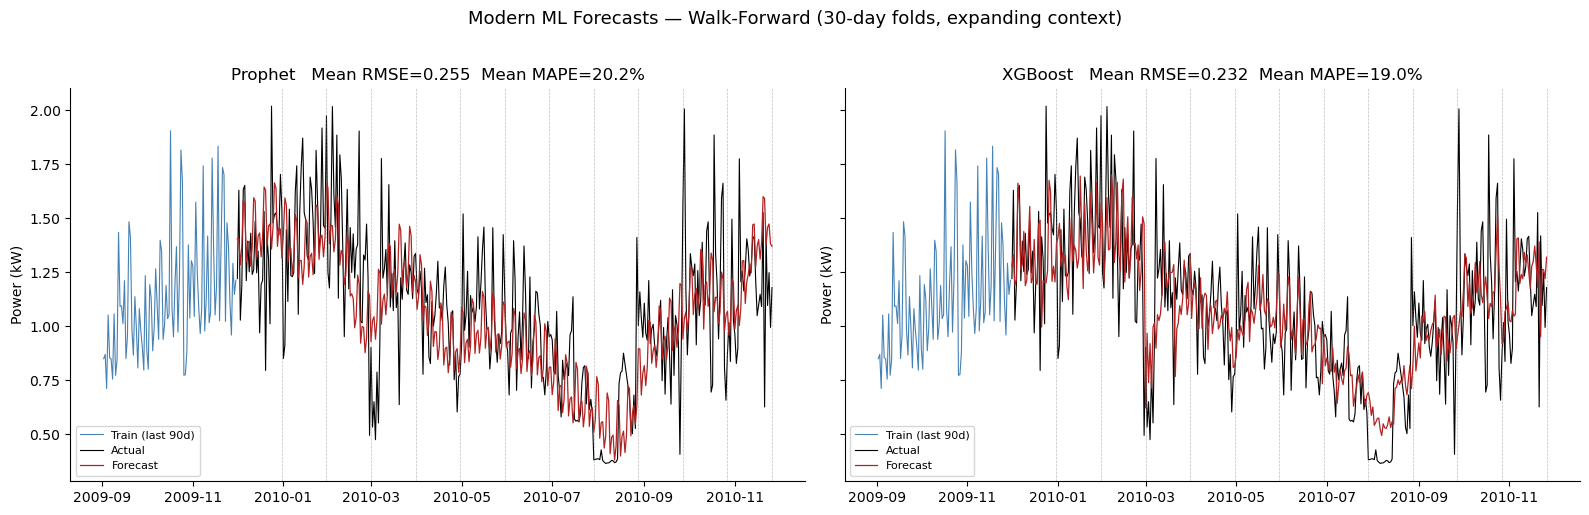

Saved → ../outputs/modern_ml_forecasts.png


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, (label, forecast) in zip(axes, [('Prophet', prophet_forecast), ('XGBoost', xgb_forecast)]):
    ax.plot(train_series.iloc[-90:], color='steelblue', linewidth=0.8, label='Train (last 90d)')
    ax.plot(test_series,             color='black',     linewidth=0.8, label='Actual')
    ax.plot(forecast,                color='firebrick', linewidth=0.9, label='Forecast')

    for s in fold_starts[1:]:
        ax.axvline(x=test_series.index[s], color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    rmse_val = metrics_modern.loc[label, 'RMSE']
    mape_val = metrics_modern.loc[label, 'MAPE']
    ax.set_title(f'{label}   Mean RMSE={rmse_val:.3f}  Mean MAPE={mape_val:.1f}%')
    ax.set_ylabel('Power (kW)')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

plt.suptitle('Modern ML Forecasts — Walk-Forward (30-day folds, expanding context)', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/modern_ml_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ../outputs/modern_ml_forecasts.png")